In [21]:
# =========================================================
# 1. IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')


In [22]:
# =========================================================
# 2. LOAD DATASET
# =========================================================

df = pd.read_csv('/kaggle/input/datasets/asadullahcreative/telecom-customer-churn-analysis/Bank_Churn_Classification_Dataset.csv'
)

print("Dataset Shape:", df.shape)

df.head()


Dataset Shape: (10000, 10)


,Unnamed: 0,CustomerID,Gender,SeniorCitizen,Tenure,MonthlyCharges,Contract,PaymentMethod,Churn,TotalCharges
0,0,0,Male,0,55,111.88,Two year,Mailed check,0,6153.40
1,1,1,Female,1,36,58.70,Two year,Electronic check,0,2113.20
2,2,2,Male,0,37,118.86,One year,Electronic check,0,4397.82
3,3,3,Male,1,14,96.14,Month-to-month,Mailed check,1,1345.96
4,4,4,Male,1,27,28.05,Two year,Mailed check,0,757.35


In [23]:
# =========================================================
# 3. DATA UNDERSTANDING
# =========================================================

print(df.info())

print(df.isnull().sum())

print(df.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      10000 non-null  int64  
 1   CustomerID      10000 non-null  int64  
 2   Gender          10000 non-null  object 
 3   SeniorCitizen   10000 non-null  int64  
 4   Tenure          10000 non-null  int64  
 5   MonthlyCharges  10000 non-null  float64
 6   Contract        10000 non-null  object 
 7   PaymentMethod   10000 non-null  object 
 8   Churn           10000 non-null  int64  
 9   TotalCharges    10000 non-null  float64
dtypes: float64(2), int64(5), object(3)
memory usage: 781.4+ KB
None
Unnamed: 0        0
CustomerID        0
Gender            0
SeniorCitizen     0
Tenure            0
MonthlyCharges    0
Contract          0
PaymentMethod     0
Churn             0
TotalCharges      0
dtype: int64
        Unnamed: 0   CustomerID  SeniorCitizen        Tenure  MonthlyC

In [24]:
# =========================================================
# 4. DATA CLEANING
# =========================================================

# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

# Remove null rows
df.dropna(inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

print("Cleaned Shape:", df.shape)



Cleaned Shape: (10000, 10)


In [25]:
df.head()

,Unnamed: 0,CustomerID,Gender,SeniorCitizen,Tenure,MonthlyCharges,Contract,PaymentMethod,Churn,TotalCharges
0,0,0,Male,0,55,111.88,Two year,Mailed check,0,6153.40
1,1,1,Female,1,36,58.70,Two year,Electronic check,0,2113.20
2,2,2,Male,0,37,118.86,One year,Electronic check,0,4397.82
3,3,3,Male,1,14,96.14,Month-to-month,Mailed check,1,1345.96
4,4,4,Male,1,27,28.05,Two year,Mailed check,0,757.35


In [26]:
# =========================================================
# 5. FEATURE ENGINEERING
# =========================================================

# ---------------------------------------------------------
# 5.1 Tenure Group
# ---------------------------------------------------------

def tenure_group(Tenure):
    if Tenure <= 12:
        return '0-1 Year'
    elif Tenure <= 24:
        return '1-2 Years'
    elif Tenure <= 48:
        return '2-4 Years'
    else:
        return '4+ Years'

df['tenure_group'] = df['Tenure'].apply(tenure_group)

# ---------------------------------------------------------
# 5.2 High Monthly Charges Flag
# ---------------------------------------------------------

df['high_monthly_charge'] = np.where(
    df['MonthlyCharges'] > df['MonthlyCharges'].mean(),
    1,
    0
)

# ---------------------------------------------------------
# 5.3 Long-Term Contract Indicator
# ---------------------------------------------------------

df['long_term_contract'] = np.where(
    df['Contract'] == 'Two year',
    1,
    0
)

# ---------------------------------------------------------
# 5.4 Customer Lifetime Value (Approximation)
# ---------------------------------------------------------

df['customer_lifetime_value'] = (
    df['MonthlyCharges'] * df['Tenure']
)


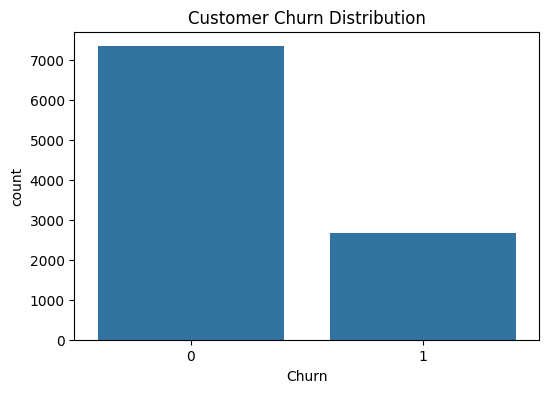

In [27]:
# =========================================================
# 6. EXPLORATORY DATA ANALYSIS (EDA)
# =========================================================

# ---------------------------------------------------------
# 6.1 Churn Distribution
# ---------------------------------------------------------

plt.figure(figsize=(6,4))

sns.countplot(x='Churn', data=df)

plt.title('Customer Churn Distribution')

plt.show()

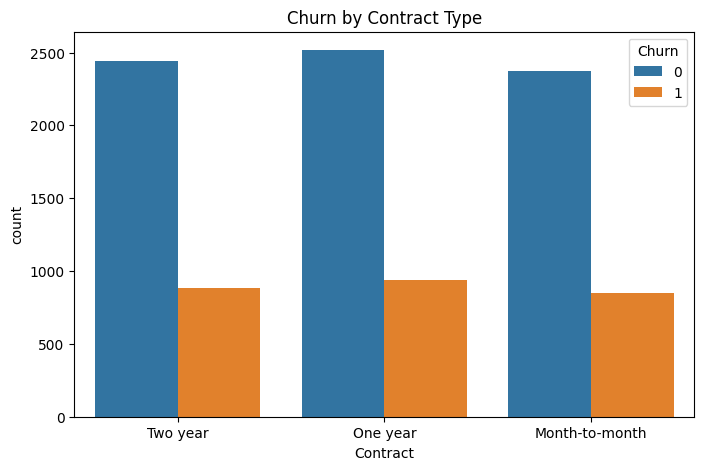

In [28]:
# =========================================================
# QUESTION 1:
# Which customers are most likely to churn?
# =========================================================

# ---------------------------------------------------------
# Churn by Contract Type
# ---------------------------------------------------------

plt.figure(figsize=(8,5))

sns.countplot(
    x='Contract',
    hue='Churn',
    data=df
)

plt.title('Churn by Contract Type')

plt.show()

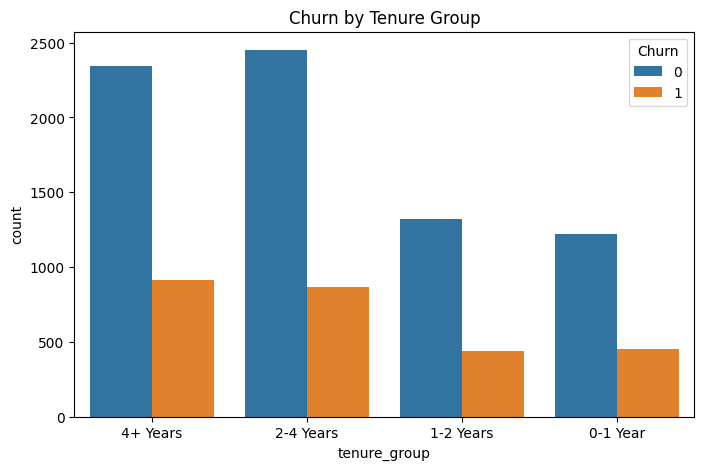

In [29]:
# ---------------------------------------------------------
# Churn by Tenure Group
# ---------------------------------------------------------

plt.figure(figsize=(8,5))

sns.countplot(
    x='tenure_group',
    hue='Churn',
    data=df
)

plt.title('Churn by Tenure Group')

plt.show()

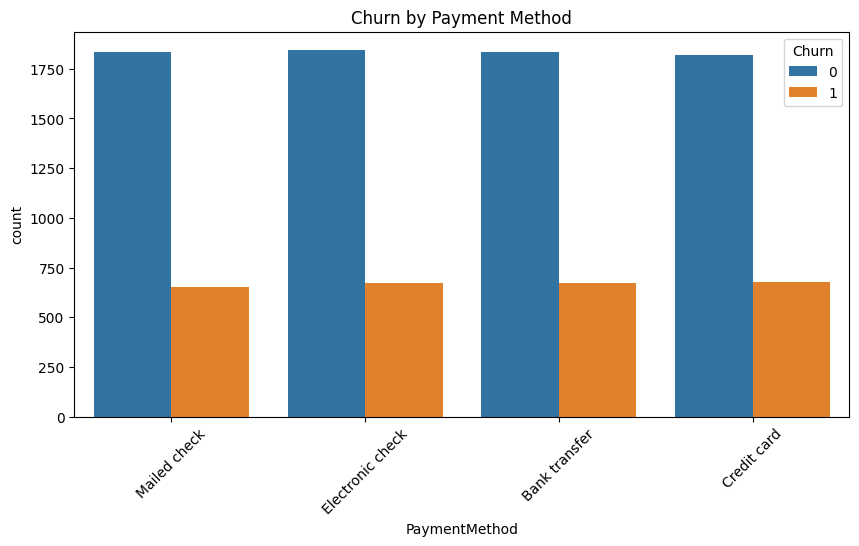

In [30]:
# =========================================================
# QUESTION 2:
# Which payment methods have highest churn?
# =========================================================

plt.figure(figsize=(10,5))

sns.countplot(
    x='PaymentMethod',
    hue='Churn',
    data=df
    )

plt.title('Churn by Payment Method')

plt.xticks(rotation=45)

plt.show()


In [31]:
# =========================================================
# QUESTION 3:
# How does contract type impact retention?
# =========================================================

contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

print(contract_churn)



Churn                   0          1
Contract                            
Month-to-month  73.718546  26.281454
One year        72.850941  27.149059
Two year        73.361395  26.638605


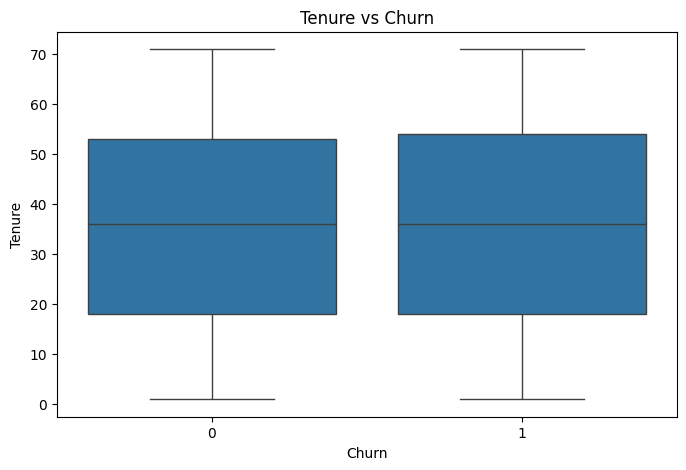

In [32]:
# =========================================================
# QUESTION 4:
# Does tenure impact churn risk?
# =========================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='Tenure',
    data=df
)

plt.title('Tenure vs Churn')

plt.show()


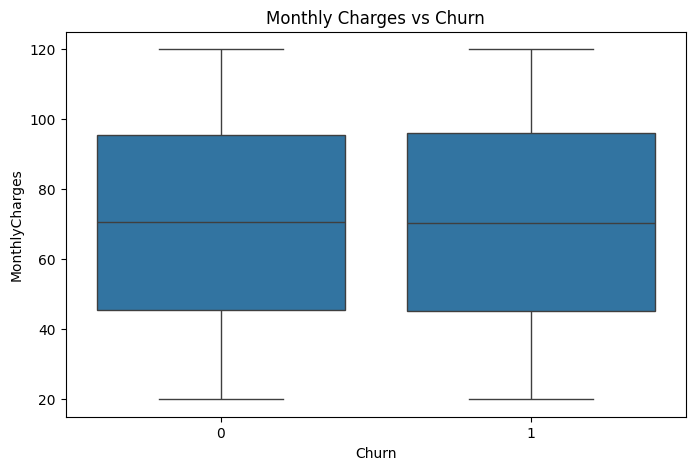

In [33]:
# =========================================================
# Monthly Charges vs Churn
# =========================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)

plt.title('Monthly Charges vs Churn')

plt.show()


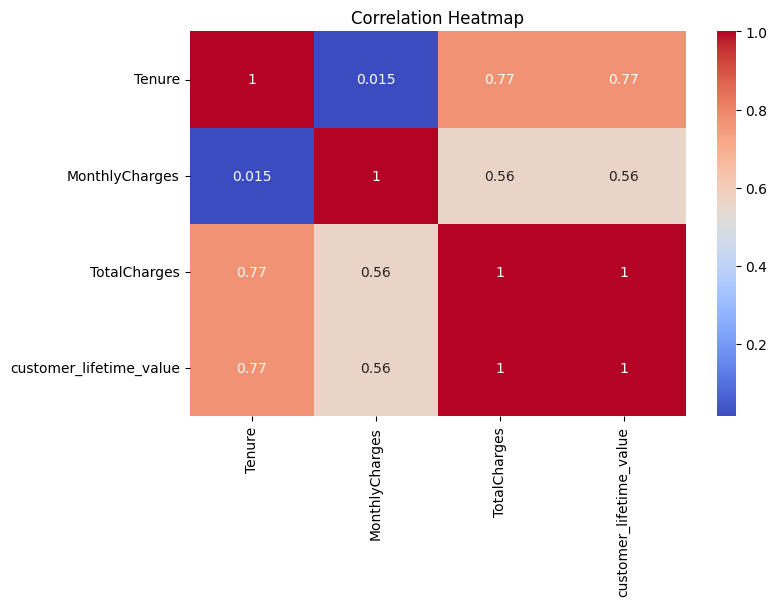

In [34]:
# =========================================================
# Correlation Heatmap
# =========================================================

numerical_cols = [
    'Tenure',
    'MonthlyCharges',
    'TotalCharges',
    'customer_lifetime_value'
]

plt.figure(figsize=(8,5))

sns.heatmap(
    df[numerical_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()


In [35]:
# =========================================================
# CLEAN TARGET COLUMN
# =========================================================

# Check unique values first
print(df['Churn'].unique())

# Convert everything to string
df['Churn'] = df['Churn'].astype(str).str.strip().str.lower()

# Encode values safely
df['Churn'] = df['Churn'].replace({
    'yes': 1,
    'no': 0,
    'true': 1,
    'false': 0
})

# Convert to numeric
df['Churn'] = pd.to_numeric(df['Churn'], errors='coerce')

# Remove null target rows
df = df.dropna(subset=['Churn'])

# Convert to integer
df['Churn'] = df['Churn'].astype(int)

# Verify results
print(df['Churn'].value_counts())

# Check dataset shape
print(df.shape)

[0 1]
Churn
0    7330
1    2670
Name: count, dtype: int64
(10000, 14)


In [36]:
# =========================================================
# 8. ENCODE CATEGORICAL VARIABLES
# =========================================================

categorical_cols = df.select_dtypes(
    include='object'
).columns


le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])


In [37]:
# =========================================================
# 9. SELECT FEATURES
# =========================================================

features = [
    'Gender',
    'SeniorCitizen',
    'Tenure',
    'Contract',
    'PaymentMethod',
    'MonthlyCharges',
    'TotalCharges',
    'high_monthly_charge',
    'long_term_contract',
    'customer_lifetime_value'
]

X = df[features]

y = df['Churn']

In [38]:
print(df.shape)

(10000, 14)


In [39]:
# =========================================================
# 10. FEATURE SCALING
# =========================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [40]:
# =========================================================
# 11. TRAIN-TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [41]:
# =========================================================
# 12. LOGISTIC REGRESSION
# =========================================================

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("\nLogistic Regression Accuracy:")
print(accuracy_score(y_test, y_pred_lr))



Logistic Regression Accuracy:
0.733


In [42]:
# =========================================================
# 13. RANDOM FOREST
# =========================================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("\nRandom Forest Accuracy:")
print(accuracy_score(y_test, y_pred_rf))




Random Forest Accuracy:
0.703


In [43]:
# =========================================================
# 14. XGBOOST
# =========================================================

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("\nXGBoost Accuracy:")
print(accuracy_score(y_test, y_pred_xgb))




XGBoost Accuracy:
0.73


In [44]:
# =========================================================
# 15. MODEL COMPARISON
# =========================================================

results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ]
})

print("\nModel Comparison:")

print(results.sort_values(
    by='Accuracy',
    ascending=False
))



Model Comparison:
                 Model  Accuracy
0  Logistic Regression     0.733
2              XGBoost     0.730
1        Random Forest     0.703


In [45]:
# =========================================================
# 16. CLASSIFICATION REPORT
# =========================================================

print("\nXGBoost Classification Report:\n")

print(classification_report(
    y_test,
    y_pred_xgb
))




XGBoost Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.99      0.84      1466
           1       0.31      0.01      0.02       534

    accuracy                           0.73      2000
   macro avg       0.52      0.50      0.43      2000
weighted avg       0.62      0.73      0.62      2000



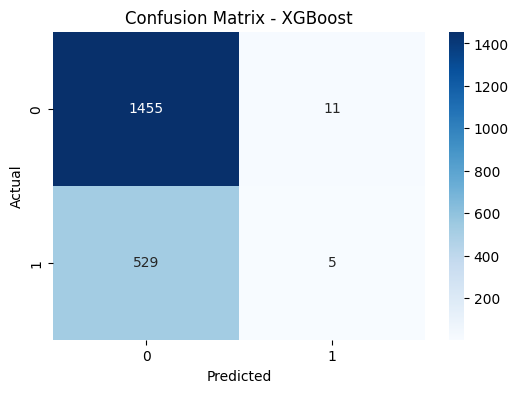

In [46]:
# =========================================================
# 17. CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix - XGBoost')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()


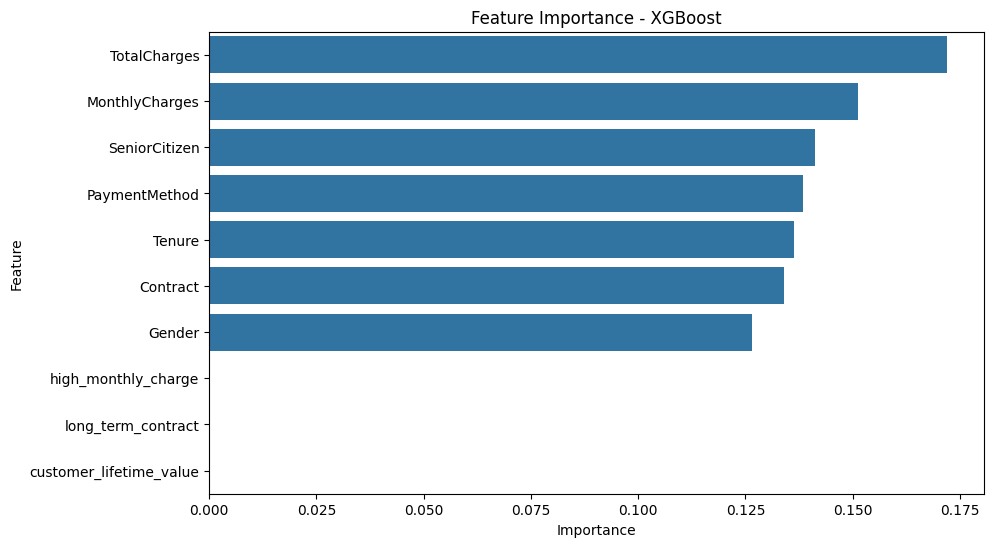

In [47]:
# =========================================================
# 18. FEATURE IMPORTANCE
# =========================================================

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df
)

plt.title('Feature Importance - XGBoost')

plt.show()


In [48]:
corr = df.corr(numeric_only=True)

corr['Churn'].sort_values(ascending=False)

Churn                      1.000000
tenure_group               0.014091
Tenure                     0.008911
TotalCharges               0.008614
customer_lifetime_value    0.008614
SeniorCitizen              0.004462
MonthlyCharges             0.003537
Contract                   0.003194
Gender                     0.000691
long_term_contract        -0.000980
high_monthly_charge       -0.002594
PaymentMethod             -0.005178
Unnamed: 0                -0.010906
CustomerID                -0.010906
Name: Churn, dtype: float64